In [325]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel



team_df = pd.read_csv("Team_data_transformed2.csv").iloc[:, 1:]

# Fill missing slope values – here we use the median rather than zero
team_df["XG_slope"] = team_df["XG_slope"].fillna(team_df["XG_slope"].median())
team_df["XGC_slope"] = team_df["XGC_slope"].fillna(team_df["XGC_slope"].median())

cluster_data=team_df[["XG_avg","XGC_avg"]].values
kmeans = KMeans(n_clusters=4, random_state=31)
kmeans.fit(cluster_data)

team_df["Cluster"]=kmeans.predict(team_df[["XG_avg","XGC_avg"]].values)

# Create opponent dataframe with selected columns
opponent_df = team_df[["code", "XGA", "XGCA", "XGH", "XGCH", "kickoff_time", "XG_slope", "XGC_slope","XG_avg","XGC_avg","Cluster","Rolling_Threat","Rolling_Threat_Against"]].copy()

# Merge team and opponent data on opponent code and kickoff time
# Suffixes indicate which data comes from team_df and which from opponent_df
pred_df = pd.merge(team_df, opponent_df, 
                   left_on=['opponent', 'kickoff_time'], 
                   right_on=['code', 'kickoff_time'], 
                   how='left', suffixes=('_team', '_opp'))

# --- 2. Construct Prediction Dataset with Clear Feature Assignment ---
print(pred_df)

new_pred_df=pd.DataFrame()
teams=pred_df["code_team"].unique()
latest_df=pd.DataFrame()
for teams_code in teams:
    code_df=pred_df[pred_df["code_team"]==teams_code]
    code_df = code_df.sort_values(by='kickoff_time')
    code_df['Cluster_XG'] = (code_df.groupby('Cluster_opp')['XG']
    .transform(lambda x: x.shift(1).rolling(window=8, min_periods=1).mean()))
    code_df['Cluster_XG'] = code_df['Cluster_XG'].fillna(code_df['Cluster_XG'].mean())

    code_df['Cluster_XGC'] = (code_df.groupby('Cluster_opp')['XGC']
    .transform(lambda x: x.shift(1).rolling(window=8, min_periods=1).mean()))
    code_df['Cluster_XGC'] = code_df['Cluster_XGC'].fillna(code_df['Cluster_XGC'].mean())
    code_df['kickoff_time'] = pd.to_datetime(code_df['kickoff_time'])
    latest_rows = code_df.loc[code_df.groupby('Cluster_opp')['kickoff_time'].idxmax()]
    latest_rows = latest_rows[['code_team','Cluster_opp', 'Cluster_XG','Cluster_XGC']]
    latest_df=pd.concat([latest_df, latest_rows], axis=0, ignore_index=True)

    new_pred_df=pd.concat([new_pred_df, code_df], axis=0, ignore_index=True)
latest_df.to_csv("Team_cluster_data.csv")
pred_df=new_pred_df.copy()
print(new_pred_df)

    
# Start with key columns from the team data
Model_pred = pred_df[["name", "kickoff_time", "was_home", "XG", "XGC","Clean_Sheet","Cluster_XG","Cluster_XGC"]].copy()

# Use vectorized operations to assign attacking and defensive stats.
# The assumption is:
# - For a home game: use home expected stats from opponent data (XGH and XGCH)
# - For an away game: use away expected stats (XGA and XGCA)
Model_pred["Own_XG"] = np.where(Model_pred["was_home"]==1, pred_df["XGH_team"], pred_df["XGA_team"])
Model_pred["Own_XGC"] = np.where(Model_pred["was_home"]==1, pred_df["XGCH_team"], pred_df["XGCA_team"])
Model_pred["Opposition_XG"] = np.where(Model_pred["was_home"]==1, pred_df["XGA_opp"], pred_df["XGH_opp"])
Model_pred["Opposition_XGC"] = np.where(Model_pred["was_home"]==1, pred_df["XGCA_opp"], pred_df["XGCH_opp"])
Model_pred["Opposition_XG_avg"] = pred_df["XG_avg_opp"]
Model_pred["Opposition_XGC_avg"] = pred_df["XGC_avg_opp"]
Model_pred["Own_XG_avg"] = pred_df["XG_avg_team"]
Model_pred["Own_XGC_avg"] = pred_df["XGC_avg_team"]

Model_pred["Opposition_Treat"] = pred_df["Rolling_Threat_opp"]
Model_pred["Opposition_TreatAgainst"] = pred_df["Rolling_Threat_Against_opp"]
Model_pred["Own_Treat"] = pred_df["Rolling_Threat_team"]
Model_pred["Own_TreatAgainst"] = pred_df["Rolling_Threat_Against_team"]


Model_pred["Own_Cluster"] = pred_df["Cluster_team"]
Model_pred["Opposition_Cluster"] = pred_df["Cluster_opp"]

# Include slope features from each source
Model_pred["Own_XG_slope"] = pred_df["XG_slope_team"]
Model_pred["Own_XGC_slope"] = pred_df["XGC_slope_team"]
Model_pred["Opponent_XG_slope"] = pred_df["XG_slope_opp"]
Model_pred["Opponent_XGC_slope"] = pred_df["XGC_slope_opp"]
Model_pred.to_csv("Team_data_preds.csv")

"""team_df=pd.read_csv("Team_data_transformed.csv").iloc[:,1:]
team_df["XG_slope"] = team_df["XG_slope"].fillna(0)
team_df["XGC_slope"] = team_df["XGC_slope"].fillna(0)
opponent_df=team_df[["code", "XGA", "XGCA", "XGH", "XGCH","kickoff_time","XG_slope","XGC_slope"]]

pred_df = pd.merge(team_df, opponent_df, left_on=['opponent', 'kickoff_time'], right_on=['code', 'kickoff_time'], how='left')
print(pred_df)

Model_pred=pred_df[["name","kickoff_time","was_home","XG","XGC"]]
Model_pred["Own_XG"]=pred_df.apply(lambda row: row[13] if row[6] else row[11], axis=1)
Model_pred["Own_XGC"]=pred_df.apply(lambda row: row[14] if row[6] else row[12], axis=1)
Model_pred["Opposition_XG"]=pred_df.apply(lambda row: row[16] if row[6] else row[18], axis=1)
Model_pred["Opposition_XGC"]=pred_df.apply(lambda row: row[17] if row[6] else row[19], axis=1)

Model_pred["Own_XG_slope"]=pred_df["XG_slope_x"].values
Model_pred["Own_XGC_slope"]=pred_df["XGC_slope_x"].values
Model_pred["Opponent_XG_slope"]=pred_df["XG_slope_y"].values
Model_pred["Opponent_XGC_slope"]=pred_df["XGC_slope_y"].values
Model_pred.to_csv("Team_data_preds.csv")"""
import numpy as np
import xgboost as xgb
from datetime import datetime

Model_pred['kickoff_time'] = pd.to_datetime(Model_pred['kickoff_time'])

# Get current year and month
current_year = datetime.today().year
current_month = datetime.today().month

# Filter for current month
test_df = Model_pred[(Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month == current_month-1)| 
               (Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month == current_month-2) ]
train_df = Model_pred[(Model_pred['kickoff_time'].dt.year < current_year) | 
                 ((Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month < current_month-2))]
train_df=train_df[train_df['kickoff_time']>'2022-12-31']

import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Define Features and Target
features = ['Own_XG','Opposition_XGC','Own_XG_slope','Opponent_XGC_slope','Own_XG_avg','Opposition_XGC_avg','Own_Cluster','Opposition_Cluster','Cluster_XG','Own_Treat','Opposition_TreatAgainst']
#features = ['Own_XG', 'Own_XGC', 'Opposition_XG', 'Opposition_XGC'] # Exclude target and date
target = 'XG'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Initialize and Train XGBoost Model
#model_xg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=5,min_child_weight=10)
#model_xg.fit(X_train, y_train)
"""
lasso = LassoCV(cv=4, random_state=1).fit(X_train, y_train)

# Select features based on the coefficients
model = SelectFromModel(lasso, prefit=True)
X_train_lasso = model.transform(X_train)
X_test_lasso = model.transform(X_test)

# Check selected features
selected_features = X_train.columns[model.get_support()]
print("Selected Features:", selected_features)
"""
model_xg=SVR(kernel='rbf', C=0.1, epsilon=0.1,gamma=0.1)
model_xg.fit(X_train, y_train)
#model_xg.fit(X_train_lasso, y_train)
# Make Predictions
y_pred = model_xg.predict(X_test)
#y_pred = model_xg.predict(X_test_lasso)

# Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse:.4f}")


import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Define Features and Target
features = ['Own_XGC', 'Opposition_XG','Own_XGC_slope','Opponent_XG_slope','Opposition_XG_avg','Own_XGC_avg','Own_Cluster','Opposition_Cluster','Cluster_XGC','Opposition_Treat','Own_TreatAgainst']
#features = ['Own_XGC', 'Opposition_XG','Own_XGC_slope','Opponent_XG_slope','Opposition_XG_avg','Own_XGC_avg','Own_Cluster','Opposition_Cluster']

#features = ['Own_XG', 'Own_XGC', 'Opposition_XG', 'Opposition_XGC']# Exclude target and date
target = 'XGC'
cs_target='Clean_Sheet'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

y_CS_train=train_df[cs_target]
y_CS_test=test_df[cs_target]

# Initialize and Train XGBoost Model
model_xgc = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=4,min_child_weight=6,gamma=0.2)
model_xgc.fit(X_train, y_train)

#model_CS = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=50, learning_rate=0.1, max_depth=4,min_child_weight=8)
model_CS = xgb.XGBClassifier(objective='binary:logistic',eval_metric='rmse', n_estimators=100, learning_rate=0.01, max_depth=4,min_child_weight=8)
model_CS = LogisticRegression()
#model_CS=SVR(kernel='rbf', C=0.1, epsilon=0.1,gamma=0.1)
model_CS.fit(X_train, y_CS_train)
"""feature_importance = pd.Series(model_CS.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)
xgb.plot_importance(model_CS, importance_type='gain')
plt.show()"""
model_xgc=SVR(kernel='rbf', C=0.1, epsilon=0.1,gamma=0.1)
model_xgc.fit(X_train, y_train)

# Make Predictions
y_pred = model_xgc.predict(X_test)
y_pred_CS = model_CS.predict_proba(X_test)[:, 1]
#y_pred_CS = model_CS.predict(X_test)
# Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse:.4f}")

mse = mean_squared_error(y_CS_test, y_pred_CS)
print(f"Mean Squared Error on CS: {mse:.4f}")
from sklearn.metrics import roc_auc_score, accuracy_score

print("ROC AUC:", roc_auc_score(y_CS_test, y_pred_CS))
print("Accuracy:", accuracy_score(y_CS_test, y_pred_CS > 0.37))
from sklearn.metrics import recall_score

# Assuming your model predicted probabilities:
y_pred_CS_binary = (y_pred_CS > 0.37).astype(int)

# Recall = correctly predicted 1s / total actual 1s
recall = recall_score(y_CS_test, y_pred_CS_binary, pos_label=1)
print(f"Recall (actual clean sheets captured): {recall:.3f}")


fixture_data=pd.read_csv("Raw_Data_24/Fantasy_season_2024_Fixtures.csv")[["event","team_a","team_h","finished"]]
team_code_data=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams2.csv")[["name","code","id"]]
team_data=pd.read_csv("Team_data_newest2.csv")[["code","XGA","XGCA","XGH","XGCH","XG_slope","XGC_slope","XG_avg","XGC_avg","Rolling_Threat","Rolling_Threat_Against"]]
team_data["Cluster"]=kmeans.predict(team_data[["XG_avg","XGC_avg"]].values)
cluster_data=pd.read_csv("Team_cluster_data.csv")[["code_team","Cluster_opp","Cluster_XG","Cluster_XGC"]]

fixture_data=fixture_data[fixture_data["finished"]==False]
#fixture_data=fixture_data[(fixture_data['event']>33)].iloc[0:,:]

min_event=fixture_data["event"].min()
horizon=9
min_event_list=[]
for i in range(horizon):
    min_event_list.append(min_event+i)

fixture_data = fixture_data[fixture_data["event"].isin(min_event_list)]


df_merged = fixture_data.merge(team_code_data, left_on='team_a', right_on='id', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(team_code_data, left_on='team_h', right_on='id', how='left')  # Left join to keep all rows from df2
predict_data=df_merged[["event"]]
predict_data["team_a"]=df_merged["code_x"].values
predict_data["team_h"]=df_merged["code_y"].values
predict_data["team_a_name"]=df_merged["name_x"].values
predict_data["team_h_name"]=df_merged["name_y"].values
df_merged = predict_data.merge(team_data[["code","XGA","XGCA","XG_slope","XGC_slope","XG_avg","XGC_avg","Cluster","Rolling_Threat","Rolling_Threat_Against"]], left_on='team_a', right_on='code', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(team_data[["code","XGH","XGCH","XG_slope","XGC_slope","XG_avg","XGC_avg","Cluster","Rolling_Threat","Rolling_Threat_Against"]], left_on='team_h', right_on='code', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(cluster_data, left_on=['code_x', 'Cluster_y'], right_on=['code_team', 'Cluster_opp'], how='left')  # Left join to keep all rows from df2
df_merged = df_merged.rename(columns={
    'Cluster_XG': 'Cluster_XG_y',
    'Cluster_XGC': 'Cluster_XGC_y'
})
df_merged = df_merged.drop(['code_team', 'Cluster_opp'], axis=1)
df_merged = df_merged.merge(cluster_data, left_on=['code_y', 'Cluster_x'], right_on=['code_team', 'Cluster_opp'], how='left')  # Left join to keep all rows from df2
df_merged = df_merged.rename(columns={
    'Cluster_XG': 'Cluster_XG_x',
    'Cluster_XGC': 'Cluster_XGC_x'
})
df_merged = df_merged.drop(['code_team', 'Cluster_opp'], axis=1)




features = ['Own_XG','Opposition_XGC','Own_XG_slope','Opponent_XGC_slope','Own_XG_avg','Opposition_XGC_avg',"Cluster","Own_Treat","Opposition_TreatAgainst"]

new_input_XG = pd.DataFrame()
new_input_XG["Own_XG"]=df_merged["XGH"]
new_input_XG["Opposition_XGC"]=df_merged["XGCA"]
new_input_XG["Own_XG_slope"]=df_merged["XG_slope_y"]
new_input_XG["Opponent_XGC_slope"]=df_merged["XGC_slope_x"]
new_input_XG["Own_XG_avg"]=df_merged["XG_avg_y"]
new_input_XG["Opposition_XGC_avg"]=df_merged["XGC_avg_x"]
new_input_XG["Own_Cluster"] = df_merged["Cluster_y"]
new_input_XG["Opposition_Cluster"] = df_merged["Cluster_x"]
new_input_XG['Cluster_XG']=df_merged["Cluster_XG_x"]
new_input_XG['Cluster_XG']=df_merged["Cluster_XG_x"]
new_input_XG['Own_Treat']=df_merged["Rolling_Threat_y"]
new_input_XG['Opposition_TreatAgainst']=df_merged["Rolling_Threat_Against_x"]



new_input_XG2 = pd.DataFrame()
new_input_XG2["Own_XG"]=df_merged["XGA"]
new_input_XG2["Opposition_XGC"]=df_merged["XGCH"]
new_input_XG2["Own_XG_slope"]=df_merged["XG_slope_x"]
new_input_XG2["Opponent_XGC_slope"]=df_merged["XGC_slope_y"]
new_input_XG2["Own_XG_avg"]=df_merged["XG_avg_x"]
new_input_XG2["Opposition_XGC_avg"]=df_merged["XGC_avg_y"]
new_input_XG2["Own_Cluster"] = df_merged["Cluster_x"]
new_input_XG2["Opposition_Cluster"] = df_merged["Cluster_y"]
new_input_XG2['Cluster_XG']=df_merged["Cluster_XG_y"]
new_input_XG2['Own_Treat']=df_merged["Rolling_Threat_x"]
new_input_XG2['Opposition_TreatAgainst']=df_merged["Rolling_Threat_Against_y"]
    
new_input_XG.to_csv("teams_preds_test.csv")


xg = model_xg.predict(new_input_XG)
xg2 = model_xg.predict(new_input_XG2)


features = ['Own_XGC', 'Opposition_XG','Own_XGC_slope','Opponent_XG_slope','Own_XGC_avg','Opposition_XG_avg','Opposition_Treat','Own_TreatAgainst']
new_input_XGC = pd.DataFrame()
new_input_XGC["Own_XGC"]=df_merged["XGCH"]
new_input_XGC["Opposition_XG"]=df_merged["XGA"]
new_input_XGC["Own_XGC_slope"]=df_merged["XGC_slope_y"]
new_input_XGC["Opponent_XG_slope"]=df_merged["XG_slope_x"]
new_input_XGC["Opposition_XG_avg"]=df_merged["XG_avg_x"]
new_input_XGC["Own_XGC_avg"]=df_merged["XGC_avg_y"]
new_input_XGC["Own_Cluster"] = df_merged["Cluster_y"]
new_input_XGC["Opposition_Cluster"] = df_merged["Cluster_x"]
new_input_XGC['Cluster_XGC']=df_merged["Cluster_XGC_x"]
new_input_XGC['Opposition_Treat']=df_merged["Rolling_Threat_x"]
new_input_XGC['Own_TreatAgainst']=df_merged["Rolling_Threat_Against_y"]
new_input_XGC.to_csv("teams_preds_test2.csv")


new_input_XGC2 = pd.DataFrame()
new_input_XGC2["Own_XGC"]=df_merged["XGCA"]
new_input_XGC2["Opposition_XG"]=df_merged["XGH"]
new_input_XGC2["Own_XGC_slope"]=df_merged["XGC_slope_x"]
new_input_XGC2["Opponent_XG_slope"]=df_merged["XG_slope_y"]
new_input_XGC2["Opposition_XG_avg"]=df_merged["XG_avg_y"]
new_input_XGC2["Own_XGC_avg"]=df_merged["XGC_avg_x"]
new_input_XGC2["Own_Cluster"] = df_merged["Cluster_x"]
new_input_XGC2["Opposition_Cluster"] = df_merged["Cluster_y"]
new_input_XGC2['Cluster_XGC']=df_merged["Cluster_XGC_y"]
new_input_XGC2['Opposition_Treat']=df_merged["Rolling_Threat_y"]
new_input_XGC2['Own_TreatAgainst']=df_merged["Rolling_Threat_Against_x"]


xgc = model_xgc.predict(new_input_XGC)
xgc2 = model_xgc.predict(new_input_XGC2)
css1=model_CS.predict_proba(new_input_XGC)[:, 1]
css2=model_CS.predict_proba(new_input_XGC2)[:, 1]
#css1=model_CS.predict(new_input_XGC)
#css2=model_CS.predict(new_input_XGC2)

result_df=pd.DataFrame()
result_df["GW"]=df_merged["event"]
result_df["pred"]=df_merged["event"]-min_event+1
result_df["home_team"]=df_merged["team_h_name"]
result_df["away_team"]=df_merged["team_a_name"]
result_df["home_code"]=df_merged["team_h"]
result_df["away_code"]=df_merged["team_a"]
result_df["home_goals"]=(xg+xgc2)/2
result_df["away_goals"]=(xgc+xg2)/2
result_df["Clean_Sheet_home"]=css1
result_df["Clean_Sheet_away"]=css2
result_df.to_csv("Team_prediction_visual.csv")

home_df=result_df[["GW", "pred"]]
home_df["team_name"]=result_df["home_team"]
home_df["team_code"]=result_df["home_code"]
home_df["XG"]=result_df["home_goals"]
home_df["XGC"]=result_df["away_goals"]
home_df["CS"]=result_df["Clean_Sheet_home"]

away_df=result_df[["GW", "pred"]]
away_df["team_name"]=result_df["away_team"]
away_df["team_code"]=result_df["away_code"]
away_df["XG"]=result_df["away_goals"]
away_df["XGC"]=result_df["home_goals"]
away_df["CS"]=result_df["Clean_Sheet_away"]

ALL_pred=pd.concat([home_df, away_df], axis=0, ignore_index=True)
ALL_pred.to_csv("Team_prediction.csv")

#0.5101
#0.5434
#75
#0.281

C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


             name  code_team  id          kickoff_time     XG    XGC  \
0     Southampton         20  17  2022-08-06T14:00:00Z  1.000  4.000   
1     Southampton         20  17  2022-08-13T14:00:00Z  2.000  2.000   
2     Southampton         20  17  2022-08-20T14:00:00Z  2.000  1.000   
3     Southampton         20  17  2022-08-27T11:30:00Z  0.000  1.000   
4     Southampton         20  17  2022-08-30T18:45:00Z  2.000  1.000   
...           ...        ...  ..                   ...    ...    ...   
2235      Ipswich         40  10  2025-04-13T13:00:00Z  1.540  2.135   
2236      Ipswich         40  10  2025-04-20T13:00:00Z  0.085  3.275   
2237      Ipswich         40  10  2025-04-26T14:00:00Z  0.050  2.925   
2238      Ipswich         40  10  2025-05-03T14:00:00Z  1.425  1.275   
2239      Ipswich         40  10  2025-05-10T14:00:00Z  0.460  1.205   

      was_home  opponent  Clean_Sheet  Threat  ...  XGCA_opp   XGH_opp  \
0        False       6.0            0   118.0  ...  1.563061 

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\1102801346.py:253: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predict_data["team_a"]=df_merged["code_x"].values
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\1102801346.py:254: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predict_data["team_h"]=df_merged["code_y"].values
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\1102801346.py:255: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

113
['Fábio_Ferreira Vieira' 'Gabriel_Fernando de Jesus'
 'Gabriel_dos Santos Magalhães' 'Kai_Havertz' 'Jurriën_Timber'
 'Jorge_Luiz Frello Filho' 'Jakub_Kiwior' 'Gabriel_Martinelli Silva'
 'Ethan_Nwaneri' 'Martin_Ødegaard' 'David_Raya Martin' 'Declan_Rice'
 'Bukayo_Saka' 'William_Saliba' 'Thomas_Partey' 'Kieran_Tierney'
 'Leandro_Trossard' 'Benjamin_White' 'Oleksandr_Zinchenko'
 'Raheem_Sterling' 'Riccardo_Calafiori' 'Myles_Lewis-Skelly'
 'Mikel_Merino' 'Leon_Bailey' 'Ross_Barkley' 'Emiliano_Buendía Stati'
 'Matty_Cash' 'Leander_Dendoncker' 'Moussa_Diaby'
 'Diego_Carlos Santos Silva' 'Lucas_Digne' 'Jhon_Durán' 'Boubacar_Kamara'
 'Ezri_Konsa Ngoyo' 'Ian_Maatsen' 'Emiliano_Martínez Romero' 'John_McGinn'
 'Tyrone_Mings' 'Kosta_Nedeljković' 'Robin_Olsen' 'Pau_Torres'
 'Jacob_Ramsey' 'Morgan_Rogers' 'Youri_Tielemans' 'Ollie_Watkins'
 'Amadou_Onana' 'Jaden_Philogene' 'Lamare_Bogarde' 'Max_Aarons'
 'Tyler_Adams' 'Jaidon_Anthony' 'David_Brooks' 'Ryan_Christie'
 'Lewis_Cook' 'Enes_Ünal' 'Hamed

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


[113, 112]
Fábio_Ferreira Vieira
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Gabriel_Fernando de Jesus
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
105    0.271467
106    0.450341
dtype: float64
105    25.9
106    25.9
Name: rolling_Threat, dtype: float64
Gabriel_dos Santos Magalhães
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
209    0.271467
210    0.450341
dtype: float64
209    3.4
210    3.4
Name: rolling_Threat, dtype: float64
Kai_Havertz0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

David_Raya Martin0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
763    0.271467
764    0.450341
dtype: float64
763    0.0
764    0.0
Name: rolling_Threat, dtype: float64
David_Raya Martin1
    GW  pred  team_name  team_code        XG       XGC        CS
4   37     1  Brentford         94  1.431415  1.389191  0.219645
39  38     2  Brentford         94  1.347919  1.063408  0.356807
Declan_Rice0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
876    0.271467
877    0.450341
dtype: float64
876    9.04
877    9.04
Name: rolling_Threat, dtype: float64
Declan_Rice1
    GW  pred team_name  team_code        XG       XGC        CS
3   37     1  West Ham         21  1.185377  

...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

   GW  pred team_name  team_code   XG  XGC   CS
0  -1    -1        -1         -1 -1.0 -1.0 -1.0
1  -1    -1        -1         -1 -1.0 -1.0 -1.0
Carlos_Alcaraz
    GW  pred    team_name  team_code        XG       XGC        CS
22  37     1  Southampton         20  0.739555  1.750351  0.112514
17  38     2  Southampton         20  0.720694  2.284922  0.054405
Wout_Weghorst
    GW  pred team_name  team_code        XG       XGC        CS
21  37     1   Man Utd          1  1.073802  1.570281  0.157834
14  38     2   Man Utd          1  1.294099  1.372697  0.190869
Keylor_Navas
    GW  pred      team_name  team_code        XG       XGC       CS
23  37     1  Nott'm Forest         17  1.216740  1.185377  0.21216
16  38     2  Nott'm Forest         17  1.102547  1.368921  0.24015
Arnaut_Danjuma
    GW  pred team_name  team_code        XG       XGC        CS
20  37     1     Spurs          6  1.317640  1.692867  0.155600
18  38     2     Spurs          6  1.544492  1.556246  0.178464
Sasa_Lukic

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

expected_goals


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:325: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:326: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

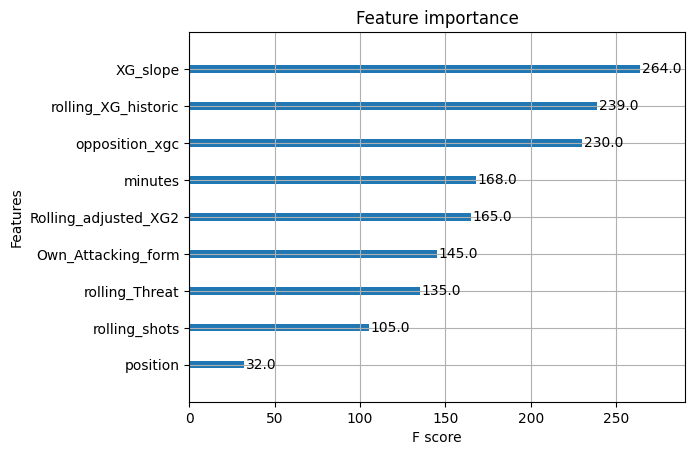

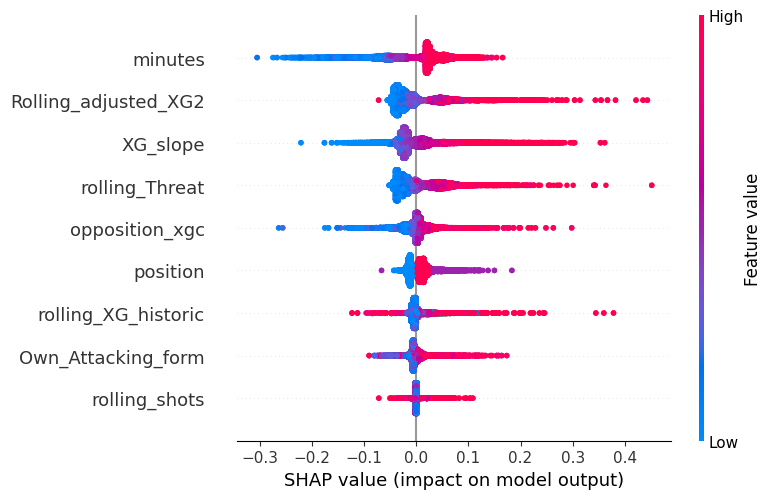

tensor(0.1214, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


[113, 112]
Fábio_Ferreira Vieira
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Gabriel_Fernando de Jesus
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
105    0.271467
106    0.450341
dtype: float64
Gabriel_dos Santos Magalhães
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
209    0.271467
210    0.450341
dtype: float64
Kai_Havertz0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Def

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Declan_Rice0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
876    0.271467
877    0.450341
dtype: float64
Declan_Rice1
    GW  pred team_name  team_code        XG       XGC        CS
3   37     1  West Ham         21  1.185377  1.216740  0.237745
32  38     2  West Ham         21  1.916870  0.846944  0.290060
Bukayo_Saka
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
1013    0.271467
1014    0.450341
dtype: float64
William_Saliba
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
1114    0.271467
1115    0.45034

...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Denis_Zakaria
    GW  pred team_name  team_code        XG       XGC        CS
1   37     1   Chelsea          8  1.570281  1.073802  0.352158
36  38     2   Chelsea          8  1.368921  1.102547  0.296518
Duje_Caleta-Car
    GW  pred    team_name  team_code        XG       XGC        CS
22  37     1  Southampton         20  0.739555  1.750351  0.112514
17  38     2  Southampton         20  0.720694  2.284922  0.054405
Wilfried_Gnonto
   GW  pred team_name  team_code   XG  XGC   CS
0  -1    -1        -1         -1 -1.0 -1.0 -1.0
1  -1    -1        -1         -1 -1.0 -1.0 -1.0
Diego_Da Silva Costa
    GW  pred team_name  team_code        XG       XGC        CS
28  37     1    Wolves         39  1.019116  1.338693  0.201160
19  38     2    Wolves         39  1.063408  1.347919  0.207949
Maximilian_Wöber
   GW  pred team_name  team_code   XG  XGC   CS
0  -1    -1        -1         -1 -1.0 -1.0 -1.0
1  -1    -1        -1         -1 -1.0 -1.0 -1.0
Carlos_Alcaraz
    GW  pred    team_name  t

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

expected_assists


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:325: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:326: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2820807214.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

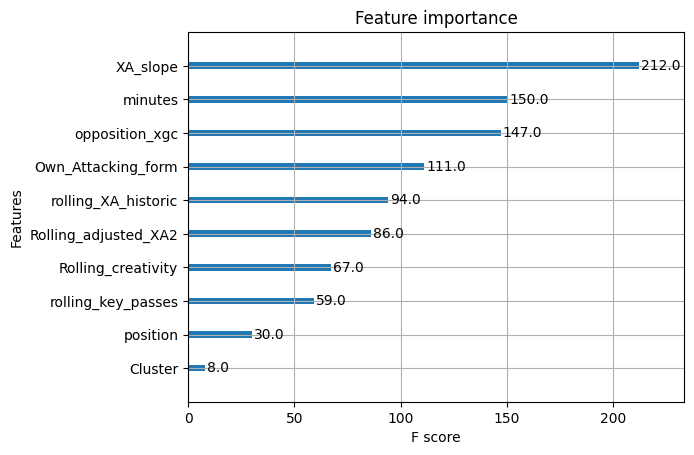

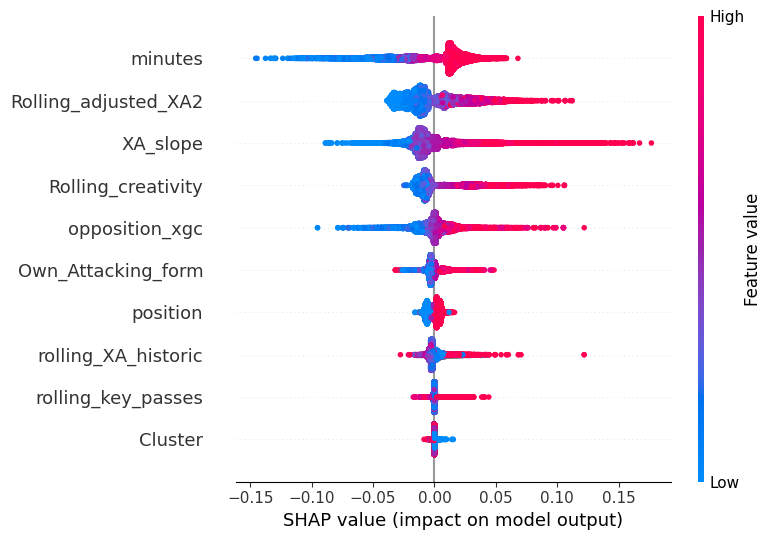

tensor(0.0923, dtype=torch.float64)


In [332]:

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from datetime import datetime, timedelta
from sklearn.preprocessing import LabelEncoder
import pytz
import torch.nn as nn
import torch
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
from sklearn.svm import SVR

criterion = nn.L1Loss()
df=pd.read_csv("testML3.csv").iloc[:,1:]
max_t=df['time'].max()
print(max_t)
names= df['name'].unique()
print(names)
time_df=pd.DataFrame()
for i in range(len(names)):
    name=names[i]
    first_filtered= df[df['name'] == name]
    unique_teamvals= first_filtered['Team'].unique()
    for t in range(len(unique_teamvals)):
        team=unique_teamvals[t]
        new_filtered= first_filtered[first_filtered['Team'] == team]
        times=[]
        filtered = new_filtered[new_filtered["minutes"] > 0]
        for g in range(len(filtered)):
            times.append(max_t-g)
        times.reverse()
        filtered["time"]=times
        if(len(unique_teamvals)>1):
            filtered['name']=filtered['name'].values[0]+str(t)
        time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)

time_df.to_csv("ML_training2.csv")
def Stat_preds(is_pred, pred_variable,column_list,horizon):
    horizon=horizon
    data=pd.read_csv("ML_training2.csv").iloc[:,1:]
    team_data=pd.read_csv("Team_prediction.csv").iloc[:,1:]
    max_time=data["time"].max()
    if(is_pred==0):
        max_time=max_time-horizon
    time_list=list(range(max_time, max_time-horizon, -1))
    opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
    data["opposition_xg"]=opp_xg
    data["opposition_xgc"]=opp_xgc
    data['rolling_Threat'] = data['rolling_Threat'].fillna(10)
    data['rolling_key_passes'] = data['rolling_key_passes'].fillna(0.5)
    data['rolling_ICT'] = data['rolling_ICT'].fillna(5)
    data['Rolling_creativity'] = data['Rolling_creativity'].fillna(10)
    
    
    pred_data=data[data['time'].isin(time_list)]
    print(time_list)
    players=data["name"].unique()
    all_preds=[]
    MSE=[]
    for i in range(len(players)):
        print(players[i])
        preds=[]
        val_preds=[]
        val_real=[]
        df=pred_data[pred_data["name"]==players[i]]
        team=df['Team'].values[-1]
        team_stats=team_data[team_data["team_code"]==team].sort_values(by='pred')
        rows_missing = horizon - len(team_stats)

        if rows_missing > 0:
            # Create a DataFrame with the required number of zero-filled rows
            zero_row = pd.DataFrame(-1, index=range(rows_missing), columns=team_stats.columns)
    
            # Concatenate to your original DataFrame
            team_stats = pd.concat([team_stats, zero_row], ignore_index=True)
        print(team_stats)
        if(len(team_stats)<1):
            continue
            
        df["team_XG"]=team_stats["XG"].values[:horizon]
        df["team_XGC"]=team_stats["XGC"].values[:horizon]
        df["team_CS"]=team_stats["CS"].values[:horizon]
        df=df.sort_values(by='time')
        df2=data[data["name"]==players[i]]
        season_filter=df2[(df2['season'] == 25)]
        if(len(season_filter)<1):
            continue

        attacking_factor=(df["opposition_xgc"]+df['team_XG'])*0.5
        defensive_factor=(df["team_CS"]+0.3/df["team_XGC"])*0.5
        print("Defensive_factor")
        print(defensive_factor)
        if(pred_variable=="GOALS"):
           print(df['rolling_Threat']) 
           df["pred"]=(df['Rolling_adjusted_XG2'])*(attacking_factor)
           real_variable="expected_goals" 
        if(pred_variable=="Assist"):
           real_variable="expected_assists"  
           df["pred"]=(df['Rolling_adjusted_XA2'])*(attacking_factor)
            
        if(pred_variable=="GC"):
            real_variable="expected_goals_conceded"
            if(df["position"].values[0] in ["FWD"]):
                continue
            team=df['Team'].values[-1]
            time_filter = data[(data['season'] == 25)]
            team_filter=time_filter[time_filter["Team"]==team]
            team_filter = team_filter.groupby('name')['minutes'].sum().reset_index()
            if(len(team_filter)<1):
                continue
            else:
                player_with_most_minutes = team_filter.loc[team_filter['minutes'].idxmax(), 'name']
                filtered_df=data[data["name"]==player_with_most_minutes]
                filtered_df = filtered_df[(filtered_df['season'] == 30)]

            df["pred"]=defensive_factor.values
            
        if(pred_variable=="bps"):
           real_variable="bonus" 
           df["pred"]=df['Rolling_adjusted_BPS2']*0.04
        
        if(pred_variable=="Fantasy"):
           real_variable="total_points"  
           df["pred"]=df['Rolling_adjusted_Fantasy2']*(df['team_XG'])
            
        preds.append(df["name"].values[0])
        df["pred"]=df["pred"].round(2)
        #if(df['pred'].isna().any()):
            #continue
        for r in range(len(df.values)):
            preds.append(df["pred"].values[r])
            val_preds.append(df["pred"].values[r])
            val_real.append(df[real_variable].values[r])
            
        preds.append(df["position"].values[0])
        all_preds.append(preds)
        #MSE.append(mean_squared_error(val_real, val_preds))
        
    columns=column_list
    data_f=pd.DataFrame(all_preds, columns=columns)
    data_f.to_csv(f"STAT_{pred_variable}_preds2.csv", index=False)
    #print(sum(MSE) / len(MSE))
def XGB_Make_dataset(position,position2):
    df=pd.read_csv("ML_training2.csv").iloc[:,1:]
    #df=df[df['position'] == position2]
    if(position in['Assist','GOALS']):
        df = df.dropna(subset=['XG_Mean_difference', 'XA_Mean_difference'])
    opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)

    df["opposition_xg"]=opp_xg
    df["opposition_xgc"]=opp_xgc

    trainingdf=df[["Cluster_XG","Cluster_XA","Threat_slope","XA_slope","XG_slope","minutes","season","opposition_xg","Average_Overscore","opposition_xgc", "rolling_form","rolling_XG","Team","name","position","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_GC","rolling_XA","time","gamepos","rolling_ICT","Overscore","XGC_DEF","XGC_FWD","XGC_MID"
                   ,"Rolling_adjusted_XG2","Rolling_adjusted_XGC2","Rolling_adjusted_XA2","rolling_GS_historic","rolling_XG_historic","goals_scored","expected_goals"
                  ,"assists","rolling_Assist_historic","rolling_Assist","rolling_XA_historic","expected_assists","rolling_GC_historic","rolling_XGC_historic","clean_sheets",
                   "expected_goals_conceded", "rolling_bps","rolling_bps_historic","rolling_bonus_historic","rolling_bonus","bonus","rolling_key_passes","rolling_shots","Own_Attacking_form","Rolling_BPS_per_90"
                  ,"XG_Mean_difference","XA_Mean_difference","Shot_Mean_difference","Adjusted_XG_Mean_difference","Threat_Mean_difference","rolling_Threat","XG_Mean","Rolling_creativity"]]
    
    
    names= df['name'].unique()
    time_df=pd.DataFrame()
    for i in range(len(names)):
        times=[]
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name].copy()
        filtered['rolling_XG'] = filtered['rolling_XG'].shift(1)
        filtered['rolling_GC'] = filtered['rolling_GC'].shift(1)
        filtered['rolling_XA'] = filtered['rolling_XA'].shift(1)
        filtered['rolling_GS_historic'] = filtered['rolling_GS_historic'].shift(1)
        filtered['rolling_XG_historic'] = filtered['rolling_XG_historic'].shift(1)
        filtered['rolling_XA_historic'] = filtered['rolling_XA_historic'].shift(1)
        filtered['rolling_Assist'] = filtered['rolling_Assist'].shift(1)
        filtered['rolling_Assist_historic'] = filtered['rolling_Assist_historic'].shift(1)
        filtered['rolling_bps'] = filtered['rolling_bps'].shift(1)
        #filtered['Rolling_adjusted_XGC'] = filtered['Rolling_adjusted_XGC'].shift(1)
        #filtered['Rolling_adjusted_XG'] = filtered['Rolling_adjusted_XG'].shift(1)
        filtered['Overscore'] = filtered['Overscore'].shift(1)
        filtered['Capped_Average_Overscore'] = np.clip(df['Average_Overscore'], None, 1.5)
        filtered['Future_XG'] = filtered['Rolling_adjusted_XG2']*filtered['opposition_xgc']
        filtered['Future_XG2'] = filtered['Rolling_adjusted_XG2']*(filtered['opposition_xgc']*0.8+0.1*filtered['Own_Attacking_form']**2)
        
        filtered['Future_XGC'] = filtered['Rolling_adjusted_XGC2']*filtered['opposition_xg']
        filtered['Future_XGA'] = filtered['Rolling_adjusted_XA2']*filtered['opposition_xgc']
        filtered['XG_diff'] = filtered["rolling_XG"]-filtered['rolling_XG_historic']
        filtered['XA_diff'] = filtered["rolling_XA"]-filtered['rolling_XA_historic']
        filtered['opposition_xgc_bucket'] = pd.cut(filtered['opposition_xgc'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)
        filtered['opposition_xg_bucket'] = pd.cut(filtered['opposition_xg'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)

        filtered['Own_Attacking_form_bucket'] = pd.cut(filtered['Own_Attacking_form'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)
        # Convert to numeric (this removes the categorical dtype)
   
        time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)
    trainingdf=time_df
    trainingdf['Team'] = trainingdf['Team'].astype('category')
    trainingdf['name'] = trainingdf['name'].astype('category')
    trainingdf['opposition_xgc_bucket'] = trainingdf['opposition_xgc_bucket'].astype(float)
    trainingdf['Own_Attacking_form_bucket'] = trainingdf['Own_Attacking_form_bucket'].astype(float)
    trainingdf['opposition_xg_bucket'] = trainingdf['opposition_xg_bucket'].astype(float)
    trainingdf['position'] = trainingdf['position'].astype('category')
    trainingdf['gamepos'] = trainingdf['gamepos'].astype('category')
    trainingdf['Shot_Mean_difference'] = trainingdf['Shot_Mean_difference'].fillna(0)
    trainingdf['Threat_Mean_difference'] = trainingdf['Threat_Mean_difference'].fillna(0)
    trainingdf['Adjusted_XG_Mean_difference'] = trainingdf['Adjusted_XG_Mean_difference'].fillna(0)
    trainingdf['XG_Mean_difference'] = trainingdf['XG_Mean_difference'].clip(lower=-1, upper=2)
    trainingdf['XA_Mean_difference'] = trainingdf['XA_Mean_difference'].clip(lower=-1, upper=3)
    trainingdf.replace([np.inf, -np.inf], 1, inplace=True)
    """if(position=='GOALS'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["position","XG_diff","opposition_xgc","Own_Attacking_form","Team","name","Cluster"
                   ,"time","minutes","Shot_Mean_difference","XG_slope","season","XG_Mean_difference","Threat_slope"]]
        target_value="XG_Mean_difference" """
    if(position=='GOALS'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["expected_goals","opposition_xgc","Own_Attacking_form","XG_slope","rolling_shots",
                               "Team","name","time","minutes","season","rolling_Threat","position","rolling_XG_historic","Rolling_adjusted_XG2"]]
        target_value="expected_goals"
        
    elif(position=='Assist2'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["XA_diff","position","opposition_xgc","Own_Attacking_form","Rolling_adjusted_XA2","Team","name","Own_cluster","Cluster"
                   ,"time","minutes","rolling_XA_historic","XA_Mean_difference","season","rolling_key_passes","XA_slope"]]
        target_value="XA_Mean_difference"
        
    elif(position=='GC'):
        trainingdf=trainingdf[trainingdf['position'] == "DEF"]
        trainingdf=trainingdf[["position","opposition_xg","Rolling_adjusted_XGC2","Team","name","Own_cluster","Cluster"
                   ,"was_home","rolling_GC","time","minutes","Future_XGC","rolling_GC_historic","rolling_XGC_historic","expected_goals_conceded","season"]]
        target_value="expected_goals_conceded"
        
    elif(position=='bps'):
        trainingdf=trainingdf[["opposition_xgc","position","opposition_xg","Own_Attacking_form","rolling_bonus_historic","rolling_bonus","bonus","Team","name","Own_cluster","Cluster"
                   ,"was_home","time","minutes","season","Future_XG","Future_XGA","Future_XGC","Rolling_BPS_per_90"]]
        target_value="bonus"
        
    elif(position=='Fantasy'):
        trainingdf=trainingdf[["total_points","opposition_xg","opposition_xgc","position","Own_Attacking_form","rolling_bonus","Team","name","Own_cluster","Cluster"
                   ,"was_home","time","minutes","season","Future_XG","Future_XGA","Future_XGC","Rolling_adjusted_XA2","rolling_key_passes","rolling_Assist","Rolling_adjusted_XG2"
                    ,"rolling_GS","rolling_GS_historic","Rolling_adjusted_XGC2","rolling_GC","rolling_form","Rolling_BPS_per_90"]]
        target_value="total_points"

    elif(position=='Assist'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["expected_assists","opposition_xgc","Own_Attacking_form","XA_slope","rolling_key_passes",
                               "Team","name","time","minutes","season","Rolling_creativity","position","rolling_XA_historic","Cluster","Rolling_adjusted_XA2"]]
        target_value="expected_assists"
        
    elif(position=='GK'):
        trainingdf=trainingdf[["opposition_xg","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GC","time","gamepos"]]
           

    else:
        trainingdf=trainingdf[["opposition_xg","opposition_xgc", "rolling_form","rolling_XG","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_XA","time","gamepos",'Future_XG',"Future_XGA"]]
    trainingdf.to_csv("xgb_test_data.csv")
    print(target_value)
    return trainingdf,target_value
    
def XGB_Train(rounds, eta,max_depth,gamma,min_c,dtrain,target_value,train,Y_train  ):
    if(target_value=='bonus'):
        params = {
            'objective': 'multi:softprob',
            'max_depth': max_depth,
            'eta': eta,
            'eval_metric': 'mlogloss',
            'tree_method': 'hist',
            'grow_policy': 'lossguide',
            'lambda': 2,
            'gamma': gamma,
            'min_child_weight': min_c,
            'num_class': 4
        }

        # Train using xgboost.train
        num_rounds = rounds
        xgb_model = xgb.train(params, dtrain, num_rounds)
        return xgb_model

    else:
        params = {
            'max_depth': max_depth,
            'eta': eta,
            'objective': 'reg:squarederror',  # Use 'reg:squarederror' for regression
            'eval_metric': 'rmse',             # Use 'rmse' (root mean squared error) for evaluation
            'tree_method':'hist',
            'grow_policy': 'lossguide',
            'lambda': 2, 
            'gamma':gamma,
            'min_child_weight': min_c
        }

        num_rounds = rounds
        xgb_model = xgb.train(params, dtrain, num_rounds)
        return xgb_model


def XGB_Make_Pred(trainingdf,target_value,position2,column_list,predlength,position):
    X_train=pd.DataFrame()
    names= trainingdf['name'].unique()


    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - predlength*2

        name_df=filtered[lambda x: x.time <= training_cutoff]
        X_train=pd.concat([X_train, name_df], axis=0, ignore_index=True)
        
    full=['Mohamed_Salah','Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen']
    
    extra=X_train[X_train['name'].isin(full)]
    extra['name'] = extra['name'].astype(str) + 'r'
    extra['name'] = extra['name'].astype('category')
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)

    full=['Mohamed_Salah']
    extra=X_train[X_train['name'].isin(full)]
    extra['name'] = extra['name'].astype(str) + 'r2'
    extra['name'] = extra['name'].astype('category')
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)
    
    X_test=pd.DataFrame()

    max_cutoff=predlength
    min_cutoff=0
    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - max_cutoff
        training_cutoff2 = filtered["time"].max() - min_cutoff
        name_df=filtered[lambda x: x.time > training_cutoff]
        name_df=name_df[lambda x: x.time <= training_cutoff2]
        X_test=pd.concat([X_test, name_df], axis=0, ignore_index=True)

    total=[]
    
    Y_train=X_train[[target_value]]
    Y_test=X_test[[target_value]]

    train = X_train.drop(columns=[target_value,'time',"name","Team","season"])
    test = X_test.drop(columns=['time'])

    dtrain = xgb.DMatrix(train, label=Y_train,enable_categorical=True)

    dtest = xgb.DMatrix(test, label=Y_test,enable_categorical=True)



    preds_list=test['name'].unique()
    test.to_csv("Debugg.csv")
    model=XGB_Train(60,0.1,5,0.1,6,dtrain,target_value,train,Y_train )
    model2=SVR(kernel='rbf', C=0.5, epsilon=0.1,gamma=0.1)
    #model2=xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.01, max_depth=5,min_child_weight=6)


    svr_train=train.drop(columns=['position'])
    svr_train=svr_train.fillna(0)
    model2.fit(svr_train,Y_train)
    row2=[]
    actuals=[]
    df2=pd.read_csv("ML_training2.csv").iloc[:,1:]
    for i in range(len(preds_list)):
        row=[]
        player=[]
        player.append(preds_list[i])
        row.append(preds_list[i])
        filtered_df = test[test['name'].isin(player)]
        min_cutoff=max(min_cutoff,1)
        xg_mean=df2[df2['name'].isin(player)]["XG_Mean"]
        xa_mean=df2[df2['name'].isin(player)]["XA_Mean"]
        xg=df2[df2['name'].isin(player)]["expected_goals"]
        xa=df2[df2['name'].isin(player)]["expected_assists"]
        if(target_value=="expected_goals_conceded"):
            team=filtered_df['Team'].values[-1]
            
            team_filter=trainingdf[trainingdf["Team"]==team]
            time_filter = team_filter[team_filter['season'] == 25]
            if(len(time_filter)<1):
                continue
            else:
                player_with_most_minutes = time_filter.loc[time_filter['minutes'].idxmax(), 'name']
                print(player_with_most_minutes)
                filtered_df=test[test["name"]==player_with_most_minutes]
        filtered.drop(columns=['time'])
        y=filtered_df[[target_value]]
        filtered_df = filtered_df.drop(columns=[target_value,'name',"Team","season"])
        dtest = xgb.DMatrix(filtered_df, label=y,enable_categorical=True)
        if(position in ["GOALS","Assist"]):
            svr_test=filtered_df.drop(columns=['position'])
            svr_test=svr_test.fillna(0)
            y_pred = model2.predict(svr_test)
        else:
            y_pred = model.predict(dtest)
        for g in range(len(y_pred)):
            
            if(target_value=="XG_Mean_difference"):
                row.append(y_pred[g]*xg_mean.values[-(max_cutoff-g)]+xg_mean.values[-(max_cutoff-g)])
                row2.append(y_pred[g]*xg_mean.values[-(max_cutoff-g)]+xg_mean.values[-(max_cutoff-g)])
                #row.append(y_pred[g])
                #row2.append(y_pred[g])
            elif(target_value=="XA_Mean_difference"):
                row.append(y_pred[g]*xa_mean.values[-(max_cutoff-g)]+xa_mean.values[-(max_cutoff-g)])
                row2.append(y_pred[g]*xa_mean.values[-(max_cutoff-g)]+xa_mean.values[-(max_cutoff-g)])
                #row.append(y_pred[g])
                #row2.append(y_pred[g])
            elif(target_value=="bonus"):
                row.append(y_pred[g][0]*0+y_pred[g][1]*1+y_pred[g][2]*2+y_pred[g][3]*3)
                row2.append(y_pred[g][0]*0+y_pred[g][1]*1+y_pred[g][2]*2+y_pred[g][3]*3)      
            else:
                row.append(y_pred[g])
                row2.append(y_pred[g])
        for t in range(len(y_pred)):
            if(target_value=="XG_Mean_difference"):
                row.append(xg.values[-(max_cutoff-t)])
                actuals.append(xg.values[-(max_cutoff-t)])
                #row.append(y.values[t][0])
                #actuals.append(y.values[t][0])
            elif(target_value=="XA_Mean_difference"):
                row.append(xa.values[-(max_cutoff-t)])
                actuals.append(xa.values[-(max_cutoff-t)])
                #row.append(y.values[t][0])
                #actuals.append(y.values[t][0])

            else:
                row.append(y.values[t][0])
                actuals.append(y.values[t][0])

        row.append(filtered_df["position"].values[0])
        total.append(row)
    from xgboost import plot_importance
    import matplotlib.pyplot as plt
    import shap

    le = LabelEncoder()
    train['position'] = le.fit_transform(train['position'])
    # Plot feature importance
    plot_importance(model, importance_type='weight')
    plt.show()
    if(target_value!="bonus"):
        explainer = shap.Explainer(model)

        # Compute SHAP values
        shap_values = explainer(train)  # X is your feature matrix
        shap.summary_plot(shap_values, train)
    
    print(criterion(torch.tensor(row2), torch.tensor(actuals)))
    column_list = []
    column_list.append("Name")
    for s in range(predlength):
        column_list.append(f"p{s+1}")
    for e in range(predlength):
        column_list.append(f"y{e+1}")
    column_list.append("position")
    columns=column_list
    data_f=pd.DataFrame(total, columns=columns)
    return data_f
    
def XGB(position,position2,column_list,predlength):
    data,target_value=XGB_Make_dataset(position,position2)
    pred=XGB_Make_Pred(data,target_value,position2,column_list,predlength,position)
    return pred
def Generate_LSTM_preds(pred,column_list,predlength):
    if(pred in ["GC","Fantasy"]):
        return 0
    data=pd.read_csv("ML_training2.csv").iloc[:,1:]
    opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
    data["opposition_xg"]=opp_xg
    data["opposition_xgc"]=opp_xgc
    unique_players=data["name"].unique()
    pred_all_players=pd.DataFrame(columns=column_list)
    window=8
    future=predlength
    for k in range(len(unique_players)):
        pred_player_df=[]
        player_name=unique_players[k]
        
        pred_player_df.append(player_name)
        
        df=data[data["name"]==unique_players[k]]
        position=df["position"].values[-1]
        past_df=df[df["season"]!=30].sort_values(by="time", ascending=True)

        test_df=df[df["season"]==25]
        if(len(test_df)<1):
            continue
        
        if(pred=="GOALS"):
            past_columns=["minutes","shots","Threat","expected_goals"]
            past_columns=["minutes","rolling_XG_historic","Threat","expected_goals"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="expected_goals"
            model_path="LSTM_Goals2.h5"
        elif(pred=="Assist"):
            past_columns=["minutes","key_passes","creativity","expected_assists"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="expected_assists"
            model_path="LSTM_Assist2.h5"
        elif(pred=="bps"):
            past_columns=["minutes","ICT","total_points","bonus"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="bonus"
            model_path="LSTM_Bonus.h5"



        past_df=past_df[past_columns]

        past_scaler = MinMaxScaler(feature_range=(0, 1))
        past_scaler.fit(data[past_columns].to_numpy())
        past_df[past_columns]=past_scaler.transform(past_df[past_columns].to_numpy())

        
        if len(past_df) < window:
            num_missing = window - len(past_df)
            zero_rows = pd.DataFrame(np.zeros((num_missing, past_df.shape[1])), columns=past_df.columns)
            past_df = pd.concat([zero_rows, past_df], ignore_index=True)

        opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
        opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)
        df["opposition_xg"]=opp_xg
        df["opposition_xgc"]=opp_xgc

        future_scaler = MinMaxScaler(feature_range=(0, 1))
        
        future_scaler.fit(data[future_columns].to_numpy())
        df[future_columns]=future_scaler.transform(df[future_columns].to_numpy())
    
        

        future_data=df[df["season"]==30].sort_values(by="time", ascending=True)
        future_data=future_data[future_columns]
        
        if len(future_data) < future:
            num_missing = future - len(future_data)
            zero_rows = pd.DataFrame(np.zeros((num_missing, future_data.shape[1])), columns=future_data.columns)
            future_data = pd.concat([zero_rows, future_data], ignore_index=True)

        
        future=len(future_data)

        past_df=past_df.iloc[-window:,:]

        X_test=[]
        X_future=[]
        for i in range(future): 
            X_test.append(past_df.values)
            X_future.append([future_data.values[i]])

        X_test = np.array(X_test)
        X_future = np.array(X_future)

        if(player_name=="Mohamed_Salah"):
            print(X_test)
            print(X_future)
        # Load the model
        model = load_model(model_path, compile=False)

        # Compile again with the correct loss function
        model.compile(optimizer='adam', loss=MeanSquaredError()) 


        predictions = model.predict([X_test, X_future])

        y_pred_rescaled = past_scaler.inverse_transform(
            np.concatenate((np.zeros((len(predictions), len(past_columns) - 1)), predictions.reshape(-1, 1)), axis=1)
        )[:, -1]
        print(y_pred_rescaled)
        for y in range(len(y_pred_rescaled)):
            pred_player_df.append(y_pred_rescaled[y])
        pred_player_df.append(position)
        append_df=pd.DataFrame([pred_player_df], columns=column_list)
        pred_all_players = pd.concat([pred_all_players, append_df], ignore_index=True)

    pred_all_players.to_csv(f"LSTM_{pred}.csv") 
def Make_Predictions ():
    predlength=2
    is_pred=1
    column_list = []
    column_list.append("Name")
    for k in range(predlength):
        column_list.append(f"p{k+1}")
    column_list.append("position")
    positions=["GOALS", "Assist","GC","bps","Fantasy"]
    positions=["GOALS", "Assist"]
    for y in range(len(positions)):
        XGB_pred=pd.DataFrame()
        position_filter=positions[y]
        Stat_preds(is_pred, position_filter,column_list,predlength)

        pred2=XGB(position_filter,"FWD",column_list,predlength)
        XGB_pred=pd.concat([XGB_pred, pred2], axis=0, ignore_index=True)
            
        XGB_pred.to_csv(f"XGB_{position_filter}_preds2.csv", index=False)
        #Generate_LSTM_preds(position_filter,column_list,predlength)

if __name__ == '__main__':
    Make_Predictions()
#0.0306
#0.0924

In [327]:
import pandas as pd
import torch
import torch.nn as nn
criterion = nn.MSELoss()
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
data=pd.read_csv("ML_training2.csv").iloc[:,1:]
opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
data["opposition_xg"]=opp_xg
data["opposition_xgc"]=opp_xgc
data["FXG"]=data['Rolling_adjusted_XG2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form']**2)
data["FXA"]=data['Rolling_adjusted_XA2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form']**2) 
data["Fbs"]=data['Rolling_adjusted_BPS']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form'])
data["Fpoints"]=data['Rolling_adjusted_Fantasy2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form'])
data=data[data["season"]!= 30]

full=['Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood1','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen','Jean-Philippe_Mateta','Kevin_De Bruyne','Morgan_Gibbs-White1','Bernardo_Veiga de Carvalho e Silva','Anthony_Gordon1'
         'Jarrod_Bowen','Lucas_Digne','Son_Heung-min','Dwight_McNeil','Ezri_Konsa Ngoyo','Alex_Iwobi1','Raúl_Jiménez1','Jamie_Vardy','Issa_Diop1','Emile_Smith Rowe1','Yoane_Wissa','Rico_Lewis','Diogo_Dalot Teixeira','Alejandro_Garnacho','Marc_Guéhi',
        'Joël_Veltman','Virgil_van Dijk','Dejan_Kulusevski','Cole_Palmer1','Marcus_Tavernier','Luis_Díaz','Ethan_Pinnock','Marcos_Senesi','Facundo_Buonanotte1','Matheus_Santos Carneiro Da Cunha','Noni_Madueke','Mohammed_Kudus','Murillo_Santiago Costa dos Santos',
         'Daniel_Muñoz','Morgan_Rogers','Mitoma_Kaoru','Ola_Aina','Dominic_Solanke-Mitchell','Jørgen_Strand Larsen','Liam_Delap','Maxence_Lacroix']
data=data[data['name'].isin(full)]



data['FXG'] = data['FXG'].fillna(0)
data['Fbs'] = data['Fbs'].fillna(0)
data['FXA'] = data['FXA'].fillna(0)
data['rolling_Threat'] = data['rolling_Threat'].fillna(5)
data['rolling_ICT'] = data['rolling_ICT'].fillna(3)
data['Fpoints'] = data['Fpoints'].fillna(3)
data['rolling_key_passes'] = data['rolling_key_passes'].fillna(0.5)

"""data_to_scale=data[["rolling_key_passes","rolling_ICT"]]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
data["PC1"]=pca_df["PC1"].values
data["PC2"]=pca_df["PC2"].values"""


X_train=data[["Fpoints","rolling_ICT","minutes"]]
y_train=data["total_points"]
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
feature_names = X_train.columns
coefficients = linear_regressor.coef_
intercept = linear_regressor.intercept_
for feature, coef in zip(feature_names, coefficients):
    print(f'{feature}: {coef:.4f}')

print(f'Intercept: {intercept:.4f}')
import statsmodels.api as sm

X_train_with_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_with_const).fit()

robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())
#R 0.183
#AIC -1.35

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2054453387.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2054453387.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


Fpoints: 0.3038
rolling_ICT: 0.1750
minutes: 0.0314
Intercept: -0.4566
                            OLS Regression Results                            
Dep. Variable:           total_points   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     331.8
Date:                Tue, 13 May 2025   Prob (F-statistic):          5.65e-198
Time:                        10:49:56   Log-Likelihood:                -14746.
No. Observations:                5492   AIC:                         2.950e+04
Df Residuals:                    5488   BIC:                         2.953e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [333]:
import pandas as pd
import torch
import torch.nn as nn
criterion = nn.MSELoss()
double=[[0],[0],[43,7,91,6],[0],[0]]
blank=[[0],[0],[0],[43,7,91,6],[0]]

double=[[0],[0],[0]]
blank=[[0],[0],[0]]

double_round=[0]
horizon=2
columns_all=["Name","p1","p2","position"]
def forwards():
    assist_weight=0.5
    goal_weight=0.5
    bonus_weight=0.5
    position="FWD"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["name"]==player_name]
        player_data=player_data[player_data["position"]=="FWD"]
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        
        Point_prediction.append(player_name)
        team=player_data["Team"].values[0]
        for u in range(horizon):
            overscore=max(0.8,player_data["Average_Overscore"].values[-((8-u))])
            overscore=min(1.4,overscore)
            overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
            overassist=min(1.8,overassist)
            fantasy=min(TFT_point_preds.values[0][u+1],8)*0+min(XGB_point_preds.values[0][u+1],8)*1
            print(LSTM_goal_preds.values[0][u+1])
            goal_point=(TFT_goal_preds.values[0][u+1]*0.6+LSTM_goal_preds.values[0][u+2]*0.0+XGB_goal_preds.values[0][u+1]*0.4)*overscore

                        
            assist_point=(TFT_assist_preds.values[0][u+1]*0.6+LSTM_assist_preds.values[0][u+2]*0.0+XGB_assist_preds.values[0][u+1]*0.4)*overassist
            
            bonus=(TFT_bps_preds.values[0][u+1]*0.6+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.4)   
            
            points=(2+goal_point*4+assist_point*3+bonus)*0.8+0.2*fantasy
            Point_prediction.append(points)
            #Actuals.append(player_data["total_points"].values[-((5-u)+5)])
            ppreds.append(points)
            #aactuals.append(player_data["total_points"].values[-((5-u)+5)])
    
        n = horizon  # Length of prediction array
        
        

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("FWD")
            
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    columns=columns_all
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
    
    
    return 1

def mid():
    assist_weight=0.5
    goal_weight=0.5
    bonus_weight=0.5
    position="MID"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="MID"]
        
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        Point_prediction.append(player_name)
        try:
            team=player_data["Team"].values[0]
            for u in range(horizon):
                overscore=max(0.8,player_data["Average_Overscore"].values[-((8-u))])
                overscore=min(1.4,overscore)
                overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
                overassist=min(1.8,overassist)
            
                fantasy=min(TFT_point_preds.values[0][u+1],8)*0.0+min(XGB_point_preds.values[0][u+1],8)*1
            
                goal_point=(TFT_goal_preds.values[0][u+1]*0.6+LSTM_goal_preds.values[0][u+2]*0.0+XGB_goal_preds.values[0][u+1]*0.4)*overscore
            
                assist_point=(TFT_assist_preds.values[0][u+1]*0.6+LSTM_assist_preds.values[0][u+2]*0.0+XGB_assist_preds.values[0][u+1]*0.4)*overassist

                bonus=(TFT_bps_preds.values[0][u+1]*0.6+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.4) 

                gc=TFT_GC_preds.values[0][u+1]
                print(gc)
                
                points=(2+goal_point*5+assist_point*3+bonus+1*gc)*0.8+0.2*fantasy
                Point_prediction.append(points)
                #Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                #aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue
        

        n = horizon  # Length of prediction array


        

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        
            
        Point_prediction.append("MID")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    columns=columns_all
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f


def defenders():
    assist_weight=0.5
    goal_weight=0.5
    XGC_weight=0.4
    bonus_weight=0.5
    position="DEF"
    ppreds=[]
    aactuals=[]
    All_preds=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]
    XGB_GC=pd.read_csv((f"XGB_{"GC"}_preds2.csv"))
    XGB_GC = XGB_GC[XGB_GC['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"Assist"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="DEF"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        XGB_GC_preds=XGB_GC[XGB_GC["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        Point_prediction.append(player_name)

        try:
            team=player_data["Team"].values[0]
            for u in range(horizon):
                overscore=max(0.8,player_data["Average_Overscore"].values[-((8-u))])
                overscore=min(1.5,overscore)
                overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
                overassist=min(2,overassist)
                fantasy=min(TFT_point_preds.values[0][u+1],8)*0+min(XGB_point_preds.values[0][u+1],8)*1
                
                goal_point=(TFT_goal_preds.values[0][u+1]*0.6+LSTM_goal_preds.values[0][u+2]*0.0+XGB_goal_preds.values[0][u+1]*0.4)*overscore
            
                assist_point=(TFT_assist_preds.values[0][u+1]*0.6+LSTM_assist_preds.values[0][u+2]*0.0+XGB_assist_preds.values[0][u+1]*0.4)*overassist
            
                bonus=(TFT_bps_preds.values[0][u+1]*0.6+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.4)   
            
                GC=TFT_GC_preds.values[0][u+1]*1+XGB_GC_preds.values[0][u+1]*0
            
                points=(1+goal_point*6+assist_point*3+bonus+4.5*GC)*0.8+0.2*fantasy
                Point_prediction.append(points)
                #Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                #aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue

        n = horizon  # Length of prediction array


        

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("DEF")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)

    columns=columns_all
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
                           
def gk():
    assist_weight=0.5
    goal_weight=0.5
    XGC_weight=0.4
    bonus_weight=0.5
    position="GKP"
    ppreds=[]
    aactuals=[]
    All_preds=[]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]
    players=TFT_points["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        print(player_name)
        player_data=players_data[players_data["position"]=="GKP"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        Point_prediction.append(player_name)

        try:
            team=player_data["Team"].values[0]
            for u in range(horizon):
                fantasy=(5*TFT_GC_preds.values[0][u+1]+1)*0.7+0.3*XGB_point_preds.values[0][u+1]
                points=fantasy
                Point_prediction.append(points)
                #Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                #aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue
        n = horizon  # Length of prediction array


        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("GK")
        
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)

    columns=columns_all
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f

def main():
    total_preds=pd.DataFrame()
    positions=["FWD", "DEF","MID","GKP"]
    for i in range(len(positions)):
        pos=positions[i]
        if(pos=="FWD"):
            preds=forwards()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
        elif(pos=="MID"):
            preds=mid()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
            
        elif(pos=="GKP"):
            preds=gk()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)

        else:
            preds=defenders()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
    
    total_preds.to_csv("All_Predictions.csv")
    
if __name__ == '__main__':
    main()

Gabriel_Fernando de Jesus
0.2548772522807121
['Gabriel_Fernando de Jesus', 4.102665373476265, 4.817064935620358, 'FWD']
[]
Kai_Havertz0
0.4307351918518542
['Kai_Havertz0', 4.3282751337462715, 5.325331074306623, 'FWD']
[]
Jhon_Durán
0.2044335055351257
['Jhon_Durán', 4.621435380803325, 4.4117812606800735, 'FWD']
[]
Ollie_Watkins
0.2058795145899057
['Ollie_Watkins', 5.010508430694987, 4.924085664966377, 'FWD']
[]
Enes_Ünal
0.1142141597718
['Enes_Ünal', 3.4767489241920266, 4.746109197342596, 'FWD']
[]
Francisco_Evanilson de Lima Barbosa
0.241277358084917
['Francisco_Evanilson de Lima Barbosa', 3.7631506024875025, 4.942795778607113, 'FWD']
[]
Igor_Thiago Nascimento Rodrigues
0.0402921553887426
['Igor_Thiago Nascimento Rodrigues', 2.6319179189647057, 2.6233501037158926, 'FWD']
[]
Yoane_Wissa
0.3996700921654701
['Yoane_Wissa', 4.619457426537301, 4.567381804463183, 'FWD']
[]
Evan_Ferguson0
0.0655436599254608
['Evan_Ferguson0', 3.0855189671180083, 3.3654857752524245, 'FWD']
[]
Evan_Ferguson1
0.

In [334]:
import pandas as pd
df=pd.read_csv("All_Predictions.csv").iloc[:,1:]
print(df)
Last_GW=35
# Melt the DataFrame to long format for 'p' and 't'
df_p = df.melt(id_vars=['Name', 'position'], value_vars=['p1', 'p2'], var_name='p_index', value_name='Predictions')

# Add time index based on the column name ('p1', 'p2', 'p3' -> 1, 2, 3)
df_p['time_index'] = Last_GW + df_p['p_index'].str.extract('(\d+)').astype(int)
 



# Drop the index columns used for melting
df_p = df_p[['Name', 'Predictions','position', 'time_index']]

# Sort and reset index if needed
df_p = df_p.sort_values(by=['Name', 'time_index']).reset_index(drop=True)
print(1)
# Print the transformed DataFrame
df_p.to_csv("Model_Predictions.csv")

                          Name        p1        p2 position
0    Gabriel_Fernando de Jesus  4.102665  4.817065      FWD
1                 Kai_Havertz0  4.328275  5.325331      FWD
2                   Jhon_Durán  4.621435  4.411781      FWD
3                Ollie_Watkins  5.010508  4.924086      FWD
4                    Enes_Ünal  3.476749  4.746109      FWD
..                         ...       ...       ...      ...
480           Łukasz_Fabiański  2.456116  2.831767       GK
481             Sam_Johnstone0  2.417912  2.423295       GK
482        José_Malheiro de Sá  2.314950  2.380944       GK
483             Antonín_Kinsky  2.092162  2.307229       GK
484                Alex_Palmer  2.307305  1.877395       GK

[485 rows x 4 columns]
1


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\997168584.py:9: SyntaxWarning: invalid escape sequence '\d'
  df_p['time_index'] = Last_GW + df_p['p_index'].str.extract('(\d+)').astype(int)
